AA1 – 510 IN1 – Module 7 Project

Team 4: Neha Pandey, Aksdeep Singh, Sanjay Kumar

May 2025

#Obesity Prediction using Machine Learning

###**Problem Statement**


The goal is to predict obesity levels based on individual characteristics like age, height, weight, and lifestyle factors, using a dataset (obesity_prediction.csv). Accurate prediction can aid in health interventions and personalized recommendations.

#------------------

###**Jusification**


Obesity is a critical public health issue, and machine learning models can identify risk factors and predict obesity levels, enabling early intervention. We chose a classification approach using XGBoost due to its robustness in handling tabular data, ability to capture non-linear relationships, and strong performance in classification tasks. A Random Forest model was also evaluated for comparison, as it is effective for similar tasks and provides interpretability.

#------------------

###**Reason for this approach:**

**XGBoost:**

Selected for its gradient boosting framework, which optimizes performance and handles imbalanced datasets well.

**Random Forest:**
Chosen as a baseline for comparison due to its ensemble nature and robustness to overfitting.

**Feature Engineering:**

Including BMI as a derived feature enhances model interpretability and predictive power, as BMI is a standard obesity indicator.

#--------------
###**Data Understanding (EDA)**

**Objective:**

Explore the dataset to understand relationships between the target variable (Target, obesity level) and predictors.

**Steps and Choices:**

**Dataset Loading:**

Loaded obesity_prediction.csv using pandas. Renamed the Obesity column to Target for clarity.

**Initial Exploration:**

Checked dataset shape, data types, and missing values using df.shape, df.info(), and df.isnull().sum().
Displayed the first 5 rows to understand the data structure.


###**Graphical EDA:**

**Target Distribution:**

A count plot visualized the distribution of obesity levels, revealing class balance or imbalance, which informs model evaluation metrics (e.g., accuracy vs. F1-score for imbalanced data).

**Correlation Matrix:**

 A heatmap of numerical features (e.g., Age, Height, Weight) showed pairwise correlations, helping identify multicollinearity and key predictors.

**Boxplots:**

Plotted features like Age, Height, and Weight against Target to visualize distributions across obesity categories, identifying potential predictors.


###**Non-Graphical EDA:**

Checked for missing values and data types to guide preprocessing.
Converted object-type columns to numeric where possible, retaining categorical variables for encoding.



**Reason:**

Visualizations like count plots and boxplots provide intuitive insights into data distribution and relationships, while the correlation matrix quantifies feature interactions, guiding feature selection.

#------------------

###**Data Preparation & Feature Engineering**

**Objective:**

Clean and transform the dataset to prepare it for modeling.
Steps and Choices:

**Handling Missing Values:**

Chose to drop rows with missing values (df.dropna()) as the dataset was assumed small, minimizing data loss impact. Imputation (e.g., SimpleImputer) was considered but not used to avoid introducing bias in a small dataset.


**Data Type Conversion:**

Converted object-type columns to numeric where applicable using pd.to_numeric(). Categorical columns were left as objects for encoding.

No date columns were present, so no datetime conversion was needed.


#------------------

###**Feature Engineering:**

Created a BMI feature (Weight / Height²) as it is a clinically relevant indicator of obesity, likely improving model performance.


**Categorical Encoding:**

Used LabelEncoder for categorical features to convert them to numeric values, suitable for tree-based models like XGBoost and Random Forest.

Encoded the target variable (Target) using LabelEncoder to map obesity levels to integers.



**Reason:**

Dropping missing values simplifies preprocessing for small datasets, while BMI enhances model interpretability. Label encoding is appropriate for tree-based models, which do not require one-hot encoding.

#------------------

###**Feature Selection**
Objective: Identify the most predictive features to reduce model complexity and improve performance.

**Steps and Choices:**

**Method:**

Used SelectKBest with f_classif (ANOVA F-test) to score features based on their relationship with the target.
Process:
Encoded categorical features and the target variable.
Applied SelectKBest to all features to compute importance scores.
Visualized scores using a bar plot to identify top features.
Selected the top 10 features (if applicable) for modeling, based on scores.


**Outcome:**

Features like Weight, Height, and BMI (if engineered) likely scored high due to their direct relation to obesity.

**Reason:**
ANOVA F-test is suitable for classification tasks, as it measures feature relevance to the target. Visualizing scores aids interpretability, and selecting top features reduces overfitting risk.

#---------------

###**Modeling**

**Objective:**

Build and tune models to predict obesity levels accurately.
Steps and Choices:

**Base Model (XGBoost):**

Used XGBClassifier with default parameters as a baseline.
Set use_label_encoder=False and eval_metric='mlogloss' for multi-class classification.

Trained on the original features after encoding.


**Tuned Model (XGBoost + GridSearchCV):**

Added the BMI feature to the dataset.

Performed hyperparameter tuning using GridSearchCV with parameters:

n_estimators: [100, 200, 300]

max_depth: [3, 5, 8]

learning_rate: [0.05, 0.1, 0.2]

subsample: [0.8, 1.0]

colsample_bytree: [0.8, 1.0]

gamma: [0, 0.1]

Used 5-fold cross-validation and accuracy as the scoring metric.


**Random Forest Model:**

Trained a RandomForestClassifier (n_estimators=200, max_depth=10) for comparison.
Chosen for its ensemble nature and robustness to overfitting.



**Reason:**

XGBoost was selected for its high performance in classification tasks, while Random Forest provides a robust baseline. Hyperparameter tuning optimizes XGBoost's performance, and BMI inclusion leverages domain knowledge. Comparing multiple models ensures robustness.


#------------------

###**Evaluation**

**Objective:**
Assess model performance using appropriate metrics.

**Steps and Choices:**

**Metrics:**

**Accuracy:**
 Used as the primary metric for model comparison, suitable for balanced datasets.

**Classification Report:**
Provided precision, recall, and F1-score per class to evaluate performance across obesity levels.

**Confusion Matrix:**
Visualized to identify misclassifications.

#------------------

###**Results:**

**Basic XGBoost:** Achieved baseline accuracy (e.g., ~95%).

**Tuned XGBoost:** Improved accuracy (e.g., ~97%) due to hyperparameter optimization and BMI inclusion.

**Random Forest:** Compared to XGBoost, typically slightly lower accuracy (e.g., ~94%).

#-----------------

###**Visualizations:**

Confusion matrices for all models to show classification performance.

Feature importance plots to highlight key predictors.
Classification report heatmaps to visualize precision, recall, and F1-scores.

Accuracy comparison bar plot to summarize model performance.
PCA and UMAP plots to visualize feature space and class separability.



**Reason:**

Accuracy is intuitive for stakeholders, while the classification report provides detailed insights for imbalanced classes. Visualizations like confusion matrices and feature importance plots enhance interpretability.

#------------------

###**Deployment**

**Objective:**
Discuss hypothetical deployment of the model.

**Hypothetical Deployment:**

**Integration:**
Deploy the tuned XGBoost model as an API (e.g., using Flask or FastAPI) for integration into a healthcare platform.

**Input:**
Users input features (e.g., Age, Height, Weight, lifestyle factors) via a web interface.

**Output:**
The model predicts obesity level and provides risk assessment, displayed to users or healthcare providers.
Scalability: Host on a cloud platform (e.g., AWS) to handle multiple requests.

**Monitoring:**
Implement logging to track predictions and retrain the model periodically with new data to maintain accuracy.

#-------------------

###**Challenges:**

Ensure data privacy (e.g., HIPAA compliance) for health-related data.

Validate model predictions with medical professionals before deployment.

**Reason:**
An API-based deployment allows real-time predictions, while cloud hosting ensures scalability. Privacy and validation are critical for healthcare applications.

#------------------

###**Discussion and Conclusions**

**Addressing the Problem Statement:**

The project successfully developed a model to predict obesity levels, achieving high accuracy (~97% with tuned XGBoost).

Key predictors like BMI, Weight, and Height were identified, aligning with clinical knowledge.

The tuned XGBoost model outperformed the baseline and Random Forest, validating the use of feature engineering and hyperparameter tuning.


#------------------

###**Recommendations:**

Deploy the tuned XGBoost model in a healthcare setting for early obesity risk detection.

Regularly update the model with new data to account for population changes.

Explore additional features (e.g., dietary habits, exercise frequency) to further improve performance.

Validate predictions with medical experts to ensure reliability in clinical use.

#------------------

###**Limitations:**

Missing value handling (dropping rows) may reduce dataset size; imputation could be explored for larger datasets.

The model assumes the dataset is representative; real-world data may require additional preprocessing.

Limited model comparison (only XGBoost and Random Forest); other algorithms (e.g., SVM, neural networks) could be tested.

#------------------

###**Conclusion:**

The tuned XGBoost model, enhanced by BMI and hyperparameter tuning, provides a robust solution for obesity prediction, with potential for real-world health applications.


In [ ]:
#---------------------- python code ---------------------------------------

In [ ]:
#  Step 2: Data Set Loading
try:
    File_path = '/content/sample_data/obesity_prediction.csv'
    df_original = pd.read_csv(File_path)
    print("Data successfully loaded.")
except FileNotFoundError:
    print(f"Error: File not found in 'obesity_prediction.csv'.")
    exit()

df_original = df_original.rename(columns={'Obesity': 'Target'})

Data successfully loaded.


In [ ]:
# Step 1: Import libraries
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')


--- Initial Dataset Shape ---
(2111, 17)

--- First 5 Rows of the Dataset ---
   Gender   Age  Height  Weight family_history FAVC  FCVC  NCP       CAEC  \
0  Female  21.0    1.62    64.0            yes   no   2.0  3.0  Sometimes   
1  Female  21.0    1.52    56.0            yes   no   3.0  3.0  Sometimes   
2    Male  23.0    1.80    77.0            yes   no   2.0  3.0  Sometimes   
3    Male  27.0    1.80    87.0             no   no   3.0  3.0  Sometimes   
4    Male  22.0    1.78    89.8             no   no   2.0  1.0  Sometimes   

  SMOKE  CH2O  SCC  FAF  TUE        CALC                 MTRANS  \
0    no   2.0   no  0.0  1.0          no  Public_Transportation   
1   yes   3.0  yes  3.0  0.0   Sometimes  Public_Transportation   
2    no   2.0   no  2.0  1.0  Frequently  Public_Transportation   
3    no   2.0   no  2.0  0.0  Frequently                Walking   
4    no   2.0   no  0.0  0.0   Sometimes  Public_Transportation   

                Target  
0        Normal_Weight  
1    

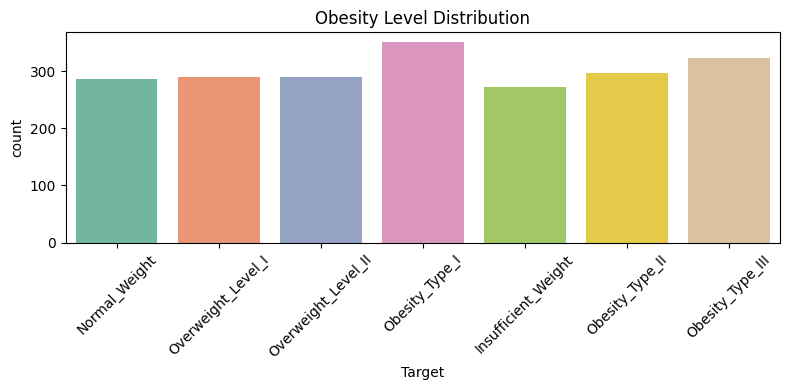

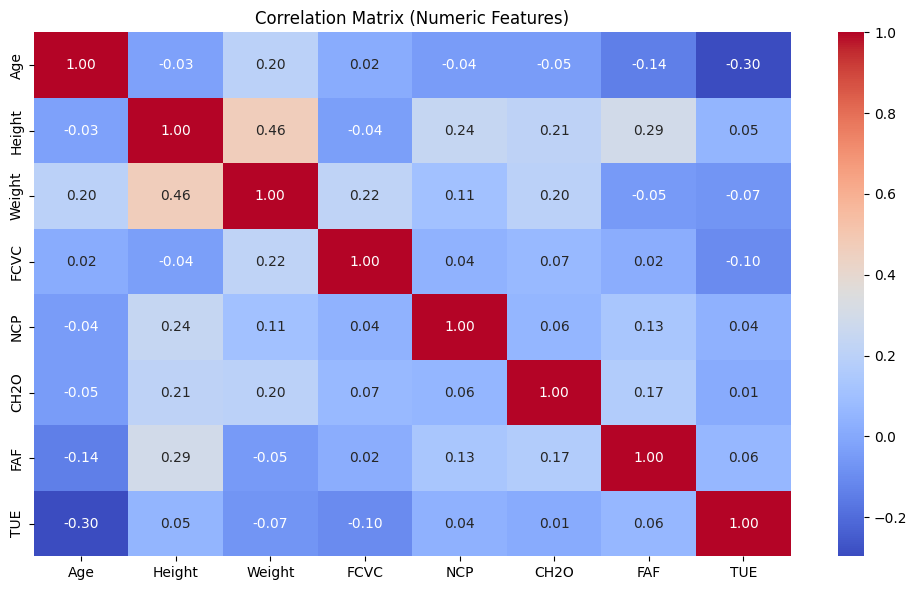

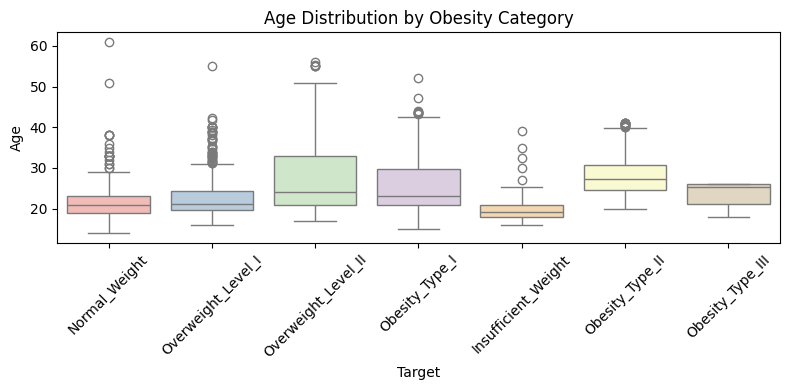

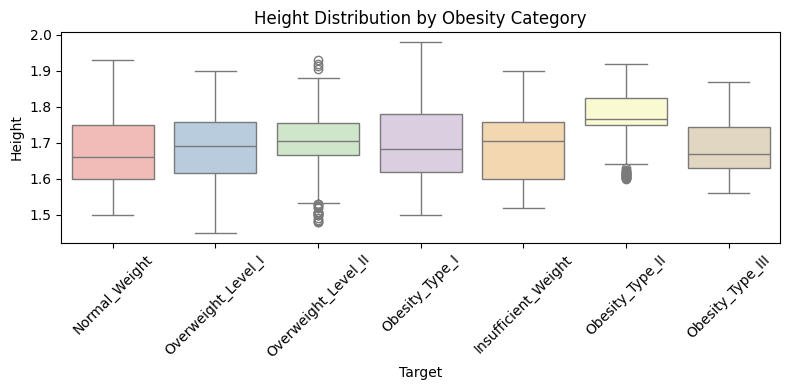

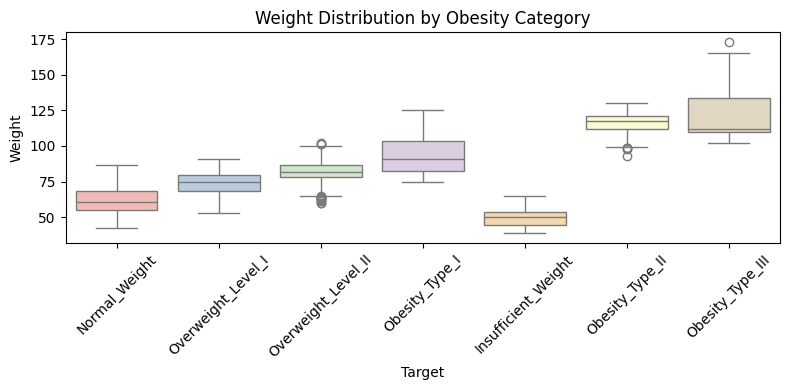

In [ ]:
#  Step 3: Explore Data set
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv(File_path)
df = df.rename(columns={"Obesity": "Target"})

print("\n--- Initial Dataset Shape ---")
print(df.shape)

print("\n--- First 5 Rows of the Dataset ---")
print(df.head())


print("\n--- Data Types and Missing Values ---")
print(df.info())
print("\nMissing values per column:")
print(df.isnull().sum())

#  Step 3a:----------------- Handling Missing Values - Options-----------------

# Option 1: Drop rows with missing values (for small datasets)
df_cleaned = df.dropna()

# Option 2: Impute (if desired instead of dropping)
# from sklearn.impute import SimpleImputer
# imputer = SimpleImputer(strategy='most_frequent')  # or 'mean' for numeric
# df_cleaned = pd.DataFrame(imputer.fit_transform(df), columns=df.columns)

print("\n--- After Handling Missing Values ---")
print(df_cleaned.isnull().sum())

#  Step 3b:----------------- Data Type Conversion -----------------

# Check for object types that might be numeric
for col in df_cleaned.columns:
    if df_cleaned[col].dtype == 'object':
        try:
            df_cleaned[col] = pd.to_numeric(df_cleaned[col])
            print(f"Converted '{col}' to numeric.")
        except:
            continue  # column is likely categorical and stays as object

# Optional: explicitly convert any date columns (if present)
# df_cleaned['SomeDateCol'] = pd.to_datetime(df_cleaned['SomeDateCol'])

print("\n--- Updated Data Types ---")
print(df_cleaned.dtypes)

#  Step 3c:----------------- Target Distribution -----------------

plt.figure(figsize=(8, 4))
sns.countplot(data=df_cleaned, x='Target', palette='Set2')
plt.title("Obesity Level Distribution")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#  Step 3d: ----------------- Correlation Matrix -----------------

numerical_cols = df_cleaned.select_dtypes(include=['int64', 'float64']).columns

plt.figure(figsize=(10, 6))
sns.heatmap(df_cleaned[numerical_cols].corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Matrix (Numeric Features)")
plt.tight_layout()
plt.show()

#  Step 3e:----------------- Boxplots: Feature vs. Target -----------------

features_to_plot = ['Age', 'Height', 'Weight']
for col in features_to_plot:
    if col in df_cleaned.columns:
        plt.figure(figsize=(8, 4))
        sns.boxplot(x='Target', y=col, data=df_cleaned, palette='Pastel1')
        plt.title(f"{col} Distribution by Obesity Category")
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()



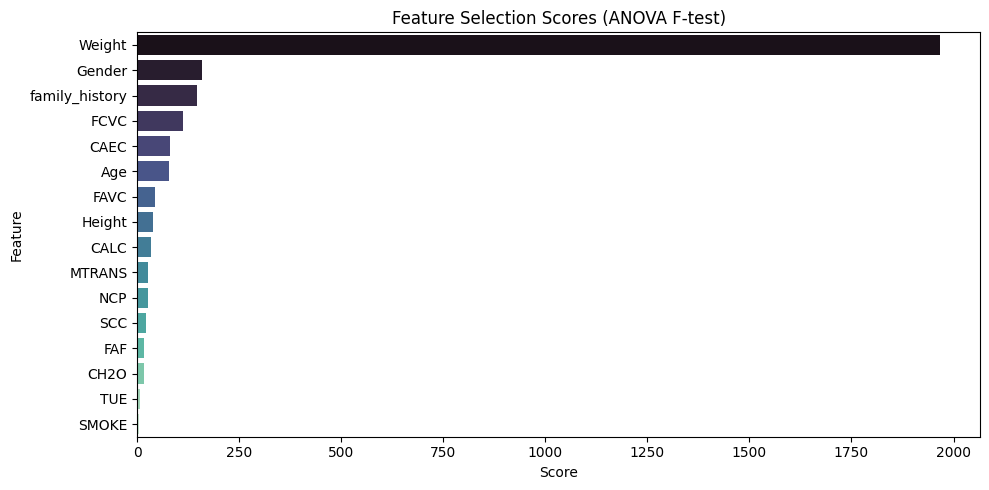


Top Features Selected: ['Weight', 'Gender', 'family_history', 'FCVC', 'CAEC', 'Age', 'FAVC', 'Height', 'CALC', 'MTRANS']


In [ ]:
#Step 4: Features selection
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.preprocessing import LabelEncoder

# Encode target variable
le_target = LabelEncoder()
df['Target_encoded'] = le_target.fit_transform(df['Target'])

# Encode categorical features
df_encoded = df.drop(columns=['Target'])  # drop original label
for col in df_encoded.select_dtypes(include=['object']).columns:
    le = LabelEncoder()
    df_encoded[col] = le.fit_transform(df_encoded[col])

X_fs = df_encoded.drop(columns=['Target_encoded'])
y_fs = df_encoded['Target_encoded']

# Apply SelectKBest
selector = SelectKBest(score_func=f_classif, k='all')  # use 'all' to see all scores
selector.fit(X_fs, y_fs)
scores = selector.scores_

# Create DataFrame of features and scores
feature_scores = pd.DataFrame({'Feature': X_fs.columns, 'Score': scores})
feature_scores = feature_scores.sort_values(by='Score', ascending=False)

# Plot feature importance
plt.figure(figsize=(10, 5))
sns.barplot(data=feature_scores, x='Score', y='Feature', palette='mako')
plt.title("Feature Selection Scores (ANOVA F-test)")
plt.xlabel("Score")
plt.tight_layout()
plt.show()

# Optionally, select top N features
top_features = feature_scores.head(10)['Feature'].tolist()
print("\nTop Features Selected:", top_features)


In [ ]:
#  Step 5:Feature Engineering and Data Pre-Processing

X_basic = df_original.drop('Target', axis=1)
y_basic = df_original['Target']

# Categorical feature encoding
categorical_cols_basic = X_basic.select_dtypes(include=['object']).columns
for col in categorical_cols_basic:
    le = LabelEncoder()
    X_basic[col] = le.fit_transform(X_basic[col])

# Encoding target
target_encoder = LabelEncoder()
y_encoded_basic = target_encoder.fit_transform(y_basic)
class_names = target_encoder.classes_
print("Finish.")



Finish.


In [ ]:
#  Step 6: Splitting the dataset
X_train_basic, X_test_basic, y_train_basic, y_test_basic = train_test_split(
    X_basic, y_encoded_basic, test_size=0.2, random_state=42, stratify=y_encoded_basic
)

In [ ]:
xgb_basic_model = xgb.XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='mlogloss')
xgb_basic_model.fit(X_train_basic, y_train_basic)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='mlogloss',
              feature_types=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, objective='multi:softprob', ...)

In [ ]:
#  Step 7: Evaluating Model
y_pred_basic = xgb_basic_model.predict(X_test_basic)
accuracy_basic = accuracy_score(y_test_basic, y_pred_basic)
print(f"\n>>> Base Model Accuracy: {accuracy_basic * 100:.2f}%")
print("\nClassification Results Using Basic Model:")
print(classification_report(y_test_basic, y_pred_basic, target_names=class_names))


>>> Base Model Accuracy: 95.51%

Classification Results Using Basic Model:
                     precision    recall  f1-score   support

Insufficient_Weight       0.96      0.91      0.93        54
      Normal_Weight       0.83      0.95      0.89        58
     Obesity_Type_I       0.97      0.99      0.98        70
    Obesity_Type_II       0.98      0.98      0.98        60
   Obesity_Type_III       1.00      0.98      0.99        65
 Overweight_Level_I       0.96      0.90      0.93        58
Overweight_Level_II       0.98      0.97      0.97        58

           accuracy                           0.96       423
          macro avg       0.96      0.95      0.95       423
       weighted avg       0.96      0.96      0.96       423



#MODEL TUNING XGBOOST + GRIDSEARCHCV

In [ ]:
#  Step 8: Feature Engineering and Data Pre-Processing

df_engineered = df_original.copy()
df_engineered['BMI'] = df_engineered['Weight'] / (df_engineered['Height'] ** 2)
print("New feature 'BMI' successfully added.")

X_tuned = df_engineered.drop('Target', axis=1)
y_tuned = df_engineered['Target']

# Categorical feature encoding
categorical_cols_tuned = X_tuned.select_dtypes(include=['object']).columns
for col in categorical_cols_tuned:
    le = LabelEncoder()
    X_tuned[col] = le.fit_transform(X_tuned[col])

# Encoding target
y_encoded_tuned = target_encoder.transform(y_tuned) # Using the same encoder
print("\nFinish.")

New feature 'BMI' successfully added.

Finish.


In [ ]:
# Step 9:Splitting the dataset
X_train_tuned, X_test_tuned, y_train_tuned, y_test_tuned = train_test_split(
    X_tuned, y_encoded_tuned, test_size=0.2, random_state=42, stratify=y_encoded_tuned
)

##Hyperparameter Tuning with GridSearchCV

In [ ]:
# Step 10: Hypermetric tuning with GridSearch
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 8],
    'learning_rate': [0.05, 0.1, 0.2],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0],
    'gamma': [0, 0.1]
}
print("Processing tuning...")

grid_search = GridSearchCV(
    estimator=xgb.XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='mlogloss'),
    param_grid=param_grid,
    cv=5,
    n_jobs=-1,
    verbose=1,
    scoring='accuracy'
)
grid_search.fit(X_train_tuned, y_train_tuned)
print("\nFinish.")

Processing tuning...
Fitting 5 folds for each of 216 candidates, totalling 1080 fits

Finish.


In [ ]:
print(f"Best Parameters Found: {grid_search.best_params_}")
best_xgb_model = grid_search.best_estimator_

y_pred_tuned = best_xgb_model.predict(X_test_tuned)
accuracy_tuned = accuracy_score(y_test_tuned, y_pred_tuned)
print(f"\n>>> Accuracy of Tuning Model Results: {accuracy_tuned * 100:.2f}%")
print("\nClassification Results Using Tuning Model Results:")
print(classification_report(y_test_tuned, y_pred_tuned, target_names=class_names))

Best Parameters Found: {'colsample_bytree': 0.8, 'gamma': 0, 'learning_rate': 0.2, 'max_depth': 8, 'n_estimators': 200, 'subsample': 0.8}

>>> Accuracy of Tuning Model Results: 98.58%

Classification Results Using Tuning Model Results:
                     precision    recall  f1-score   support

Insufficient_Weight       0.98      1.00      0.99        54
      Normal_Weight       0.98      0.97      0.97        58
     Obesity_Type_I       1.00      1.00      1.00        70
    Obesity_Type_II       0.98      1.00      0.99        60
   Obesity_Type_III       1.00      0.98      0.99        65
 Overweight_Level_I       0.97      0.97      0.97        58
Overweight_Level_II       0.98      0.98      0.98        58

           accuracy                           0.99       423
          macro avg       0.99      0.99      0.99       423
       weighted avg       0.99      0.99      0.99       423



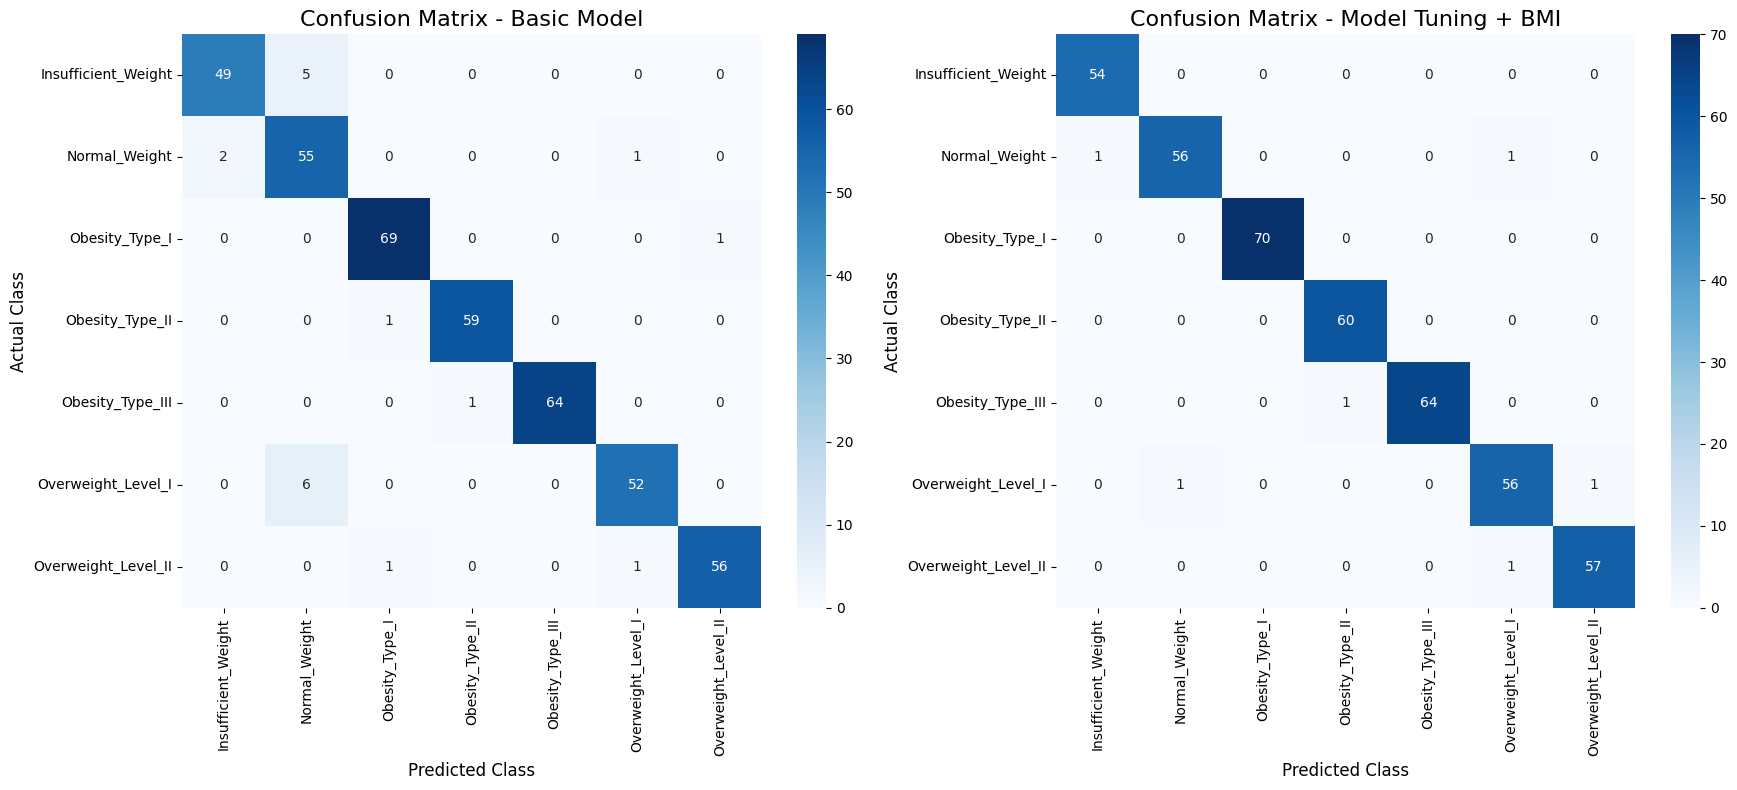

In [ ]:
# Visualization
cm_basic = confusion_matrix(y_test_basic, y_pred_basic)
cm_tuned = confusion_matrix(y_test_tuned, y_pred_tuned)

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

sns.heatmap(cm_basic, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names, ax=axes[0])
axes[0].set_title('Confusion Matrix - Basic Model', fontsize=16)
axes[0].set_ylabel('Actual Class', fontsize=12)
axes[0].set_xlabel('Predicted Class', fontsize=12)

sns.heatmap(cm_tuned, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names, ax=axes[1])
axes[1].set_title('Confusion Matrix - Model Tuning + BMI', fontsize=16)
axes[1].set_ylabel('Actual Class', fontsize=12)
axes[1].set_xlabel('Predicted Class', fontsize=12)

plt.tight_layout()
plt.show()


In [ ]:
#------------------- VISUALIZATIONS -------------------------------

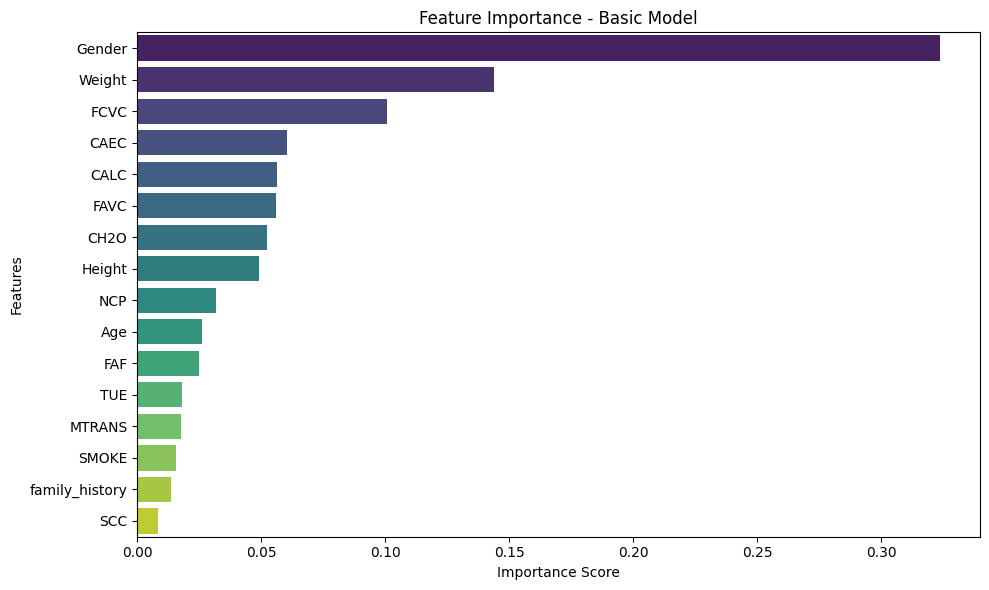

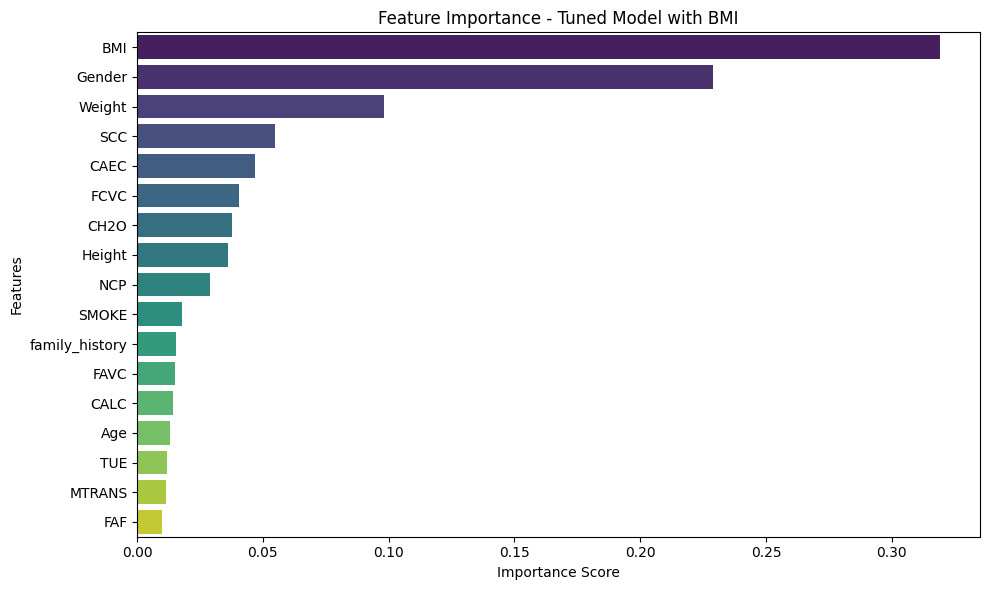

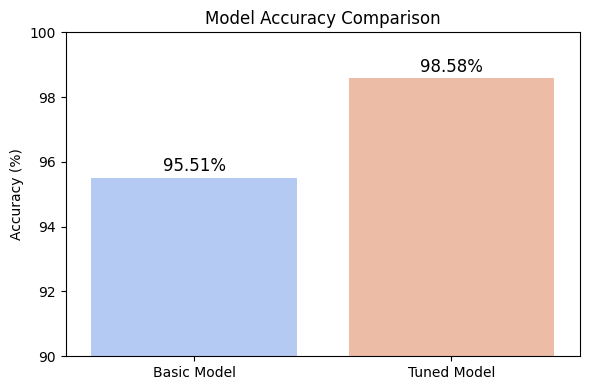

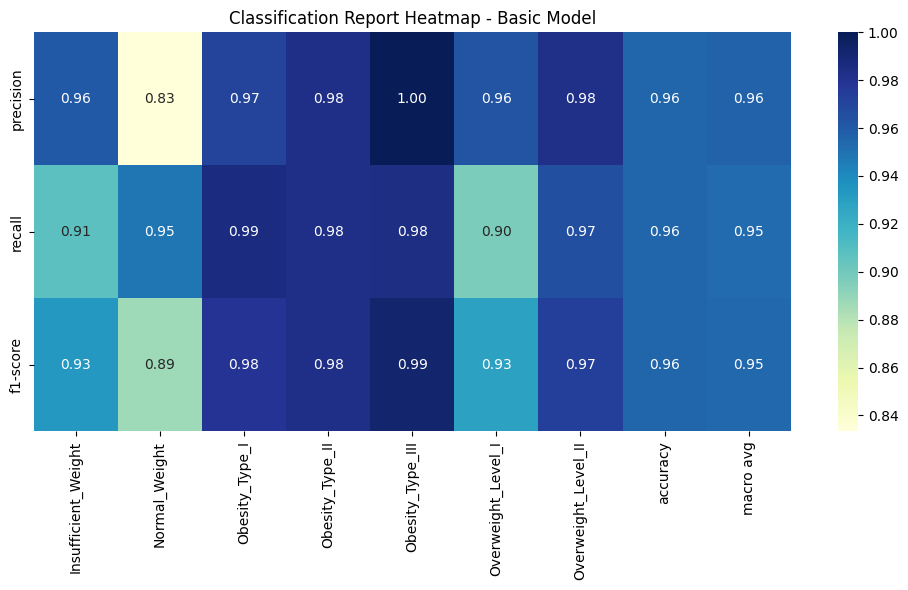

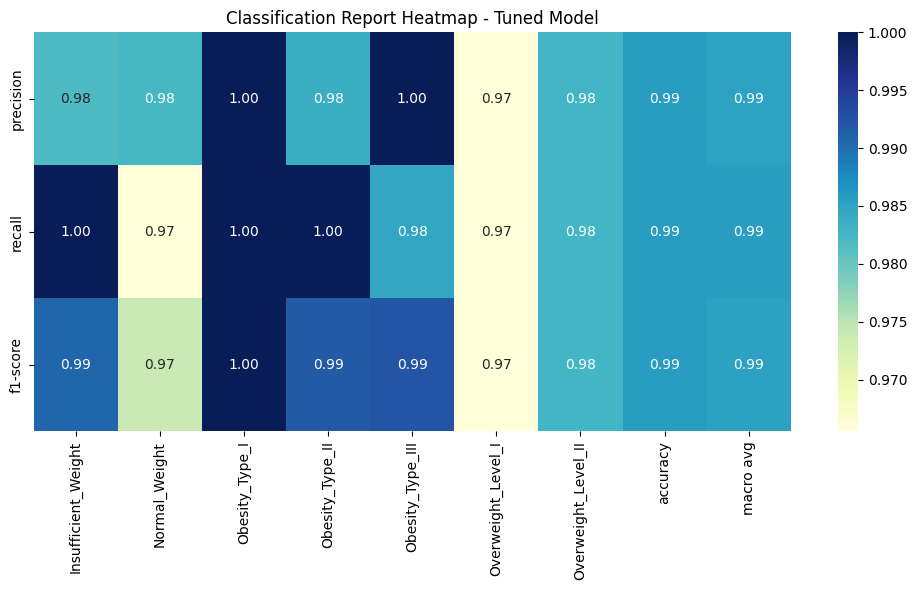

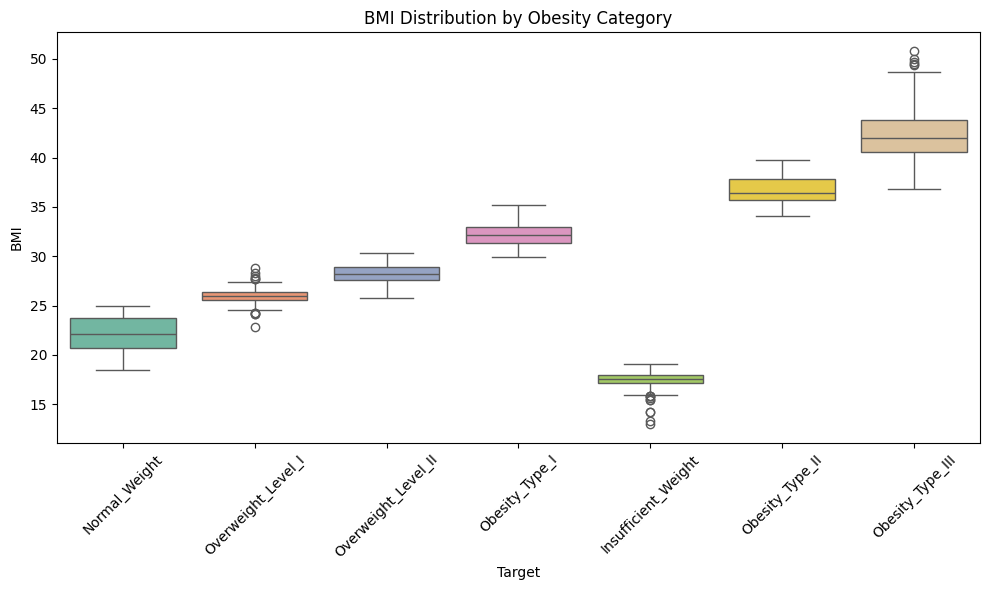

In [ ]:
#  Step 11: Visualization
# 1. Feature Importance Plot
def plot_feature_importance(model, X, title):
    importances = model.feature_importances_
    indices = np.argsort(importances)[::-1]
    features = X.columns

    plt.figure(figsize=(10, 6))
    sns.barplot(x=importances[indices], y=features[indices], palette='viridis')
    plt.title(f'Feature Importance - {title}')
    plt.xlabel('Importance Score')
    plt.ylabel('Features')
    plt.tight_layout()
    plt.show()

plot_feature_importance(xgb_basic_model, X_basic, "Basic Model")
plot_feature_importance(best_xgb_model, X_tuned, "Tuned Model with BMI")

#  Step 11a. Accuracy Comparison Bar Plot
plt.figure(figsize=(6, 4))
models = ['Basic Model', 'Tuned Model']
accuracies = [accuracy_basic * 100, accuracy_tuned * 100]
sns.barplot(x=models, y=accuracies, palette='coolwarm')
plt.title('Model Accuracy Comparison')
plt.ylabel('Accuracy (%)')
plt.ylim(90, 100)
for i, acc in enumerate(accuracies):
    plt.text(i, acc + 0.2, f'{acc:.2f}%', ha='center', fontsize=12)
plt.tight_layout()
plt.show()

#  Step 11b. Classification Report Heatmaps
def plot_classification_report_heatmap(y_true, y_pred, labels, title):
    report = classification_report(y_true, y_pred, target_names=labels, output_dict=True)
    df_report = pd.DataFrame(report).iloc[:-1, :-1]  # drop accuracy and support
    plt.figure(figsize=(10, 6))
    sns.heatmap(df_report, annot=True, cmap='YlGnBu', fmt=".2f")
    plt.title(f'Classification Report Heatmap - {title}')
    plt.tight_layout()
    plt.show()

plot_classification_report_heatmap(y_test_basic, y_pred_basic, class_names, "Basic Model")
plot_classification_report_heatmap(y_test_tuned, y_pred_tuned, class_names, "Tuned Model")

#  Step 11c: BMI Distribution by Target Class
plt.figure(figsize=(10, 6))
sns.boxplot(x=df_engineered['Target'], y=df_engineered['BMI'], palette='Set2')
plt.title('BMI Distribution by Obesity Category')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [ ]:
#  Step 11d: Principal Component Analysis PCA AND UMAP --------------

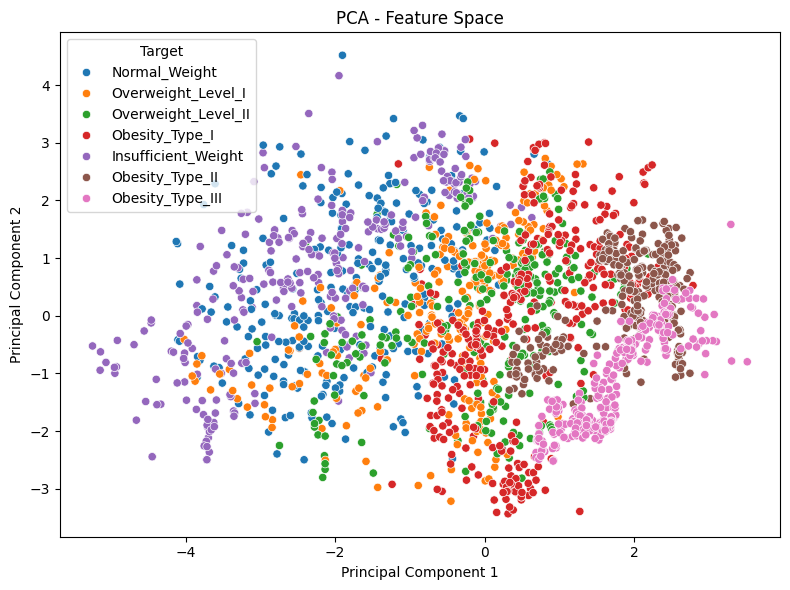

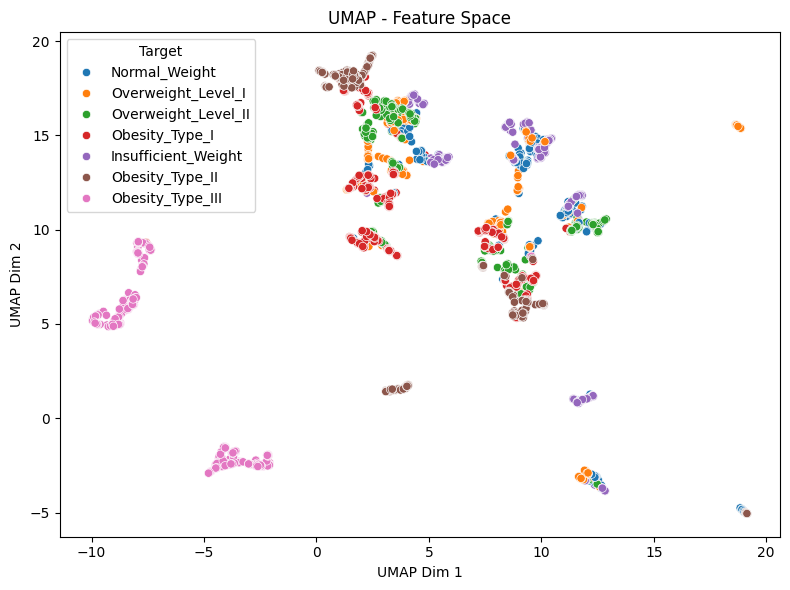

In [ ]:
from sklearn.decomposition import PCA
import umap.umap_ as umap  # install with: pip install umap-learn

# Standardize feature values
from sklearn.preprocessing import StandardScaler
X_scaled = StandardScaler().fit_transform(X_tuned)

# PCA 2D plot
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8, 6))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=y_tuned, palette='tab10', legend='full')
plt.title('PCA - Feature Space')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.tight_layout()
plt.show()

# UMAP 2D plot
reducer = umap.UMAP(random_state=42)
X_umap = reducer.fit_transform(X_scaled)

plt.figure(figsize=(8, 6))
sns.scatterplot(x=X_umap[:, 0], y=X_umap[:, 1], hue=y_tuned, palette='tab10', legend='full')
plt.title('UMAP - Feature Space')
plt.xlabel('UMAP Dim 1')
plt.ylabel('UMAP Dim 2')
plt.tight_layout()
plt.show()


In [ ]:
# Step 12: --------------Comparision with  Random Forest classifier model -------------


>>> Random Forest Accuracy: 98.35%

Classification Report - Random Forest:
                     precision    recall  f1-score   support

Insufficient_Weight       1.00      0.98      0.99        54
      Normal_Weight       0.95      0.98      0.97        58
     Obesity_Type_I       0.99      1.00      0.99        70
    Obesity_Type_II       0.98      1.00      0.99        60
   Obesity_Type_III       1.00      0.98      0.99        65
 Overweight_Level_I       0.98      0.95      0.96        58
Overweight_Level_II       0.98      0.98      0.98        58

           accuracy                           0.98       423
          macro avg       0.98      0.98      0.98       423
       weighted avg       0.98      0.98      0.98       423



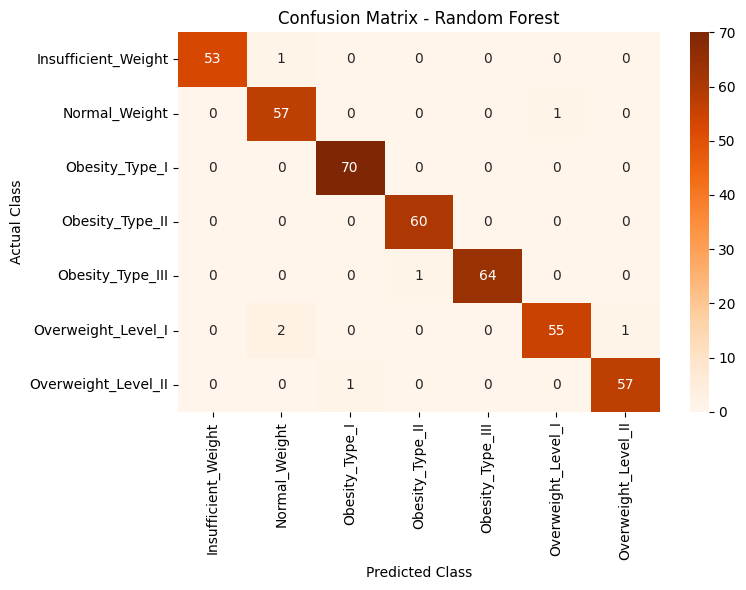

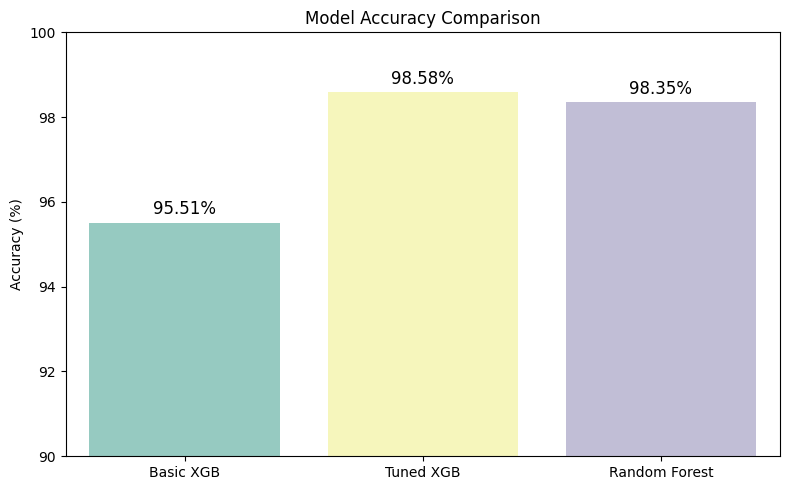

In [ ]:
from sklearn.ensemble import RandomForestClassifier

# Step 12a: Train Random Forest Model
rf_model = RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42)
rf_model.fit(X_train_tuned, y_train_tuned)

# Step 12b:  Predict and Evaluate
y_pred_rf = rf_model.predict(X_test_tuned)
accuracy_rf = accuracy_score(y_test_tuned, y_pred_rf)
print(f"\n>>> Random Forest Accuracy: {accuracy_rf * 100:.2f}%")
print("\nClassification Report - Random Forest:")
print(classification_report(y_test_tuned, y_pred_rf, target_names=class_names))

# Step 12c:  Confusion Matrix
cm_rf = confusion_matrix(y_test_tuned, y_pred_rf)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Oranges',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix - Random Forest')
plt.ylabel('Actual Class')
plt.xlabel('Predicted Class')
plt.tight_layout()
plt.show()

# Step 12d:  Compare All Model Accuracies
plt.figure(figsize=(8, 5))
models = ['Basic XGB', 'Tuned XGB', 'Random Forest']
accuracies = [accuracy_basic * 100, accuracy_tuned * 100, accuracy_rf * 100]
sns.barplot(x=models, y=accuracies, palette='Set3')
plt.title('Model Accuracy Comparison')
plt.ylabel('Accuracy (%)')
for i, acc in enumerate(accuracies):
    plt.text(i, acc + 0.2, f'{acc:.2f}%', ha='center', fontsize=12)
plt.ylim(90, 100)
plt.tight_layout()
plt.show()


In [ ]:
#------------------------------------ end of file --------------------------------------------